# Multilingual RAG System — Data Processing & Demo Notebook

This notebook walks through:
1. Dataset processing & statistics
2. Embedding visualisation (UMAP)
3. End-to-end retrieval demo
4. Evaluation results

In [2]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
print('Imports OK')

Imports OK


## 1. Dataset Processing

In [3]:
from src.data.processor import DatasetProcessor

processor = DatasetProcessor(max_samples=57)
documents = processor.run()
df = DatasetProcessor.to_dataframe(documents)

print(f'Total chunks: {len(df)}')
df.head()

2026-03-30 13:29:31 [info     ] Starting dataset processing pipeline…


C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-03-30 13:29:44 [info     ] Loading Natural Questions from HuggingFace…
2026-03-30 13:29:44 [warning  ] HuggingFace load failed (Dataset 'google/natural_questions' doesn't exist on the Hub or cannot be accessed.); falling back to synthetic data.
2026-03-30 13:29:44 [warning  ] Using synthetic dataset – real data not found.
2026-03-30 13:29:44 [info     ] Loaded 57 raw records.        


Processing records: 100%|██████████| 57/57 [00:00<00:00, 6126.84it/s]


2026-03-30 13:29:44 [info     ] Processing complete: 57 chunks from 57 valid records (0 skipped).
Total chunks: 57


,doc_id,text,source_question,source_answer,answer_type,domain,difficulty,language,token_count,chunk_index,total_chunks
0,doc_000000_chunk_000,Question: What is the capital of France? Answe...,What is the capital of France?,Paris,short,descriptive,easy,en,12,0,1
1,doc_000001_chunk_000,Question: Who wrote Romeo and Juliet? Answer: ...,Who wrote Romeo and Juliet?,William Shakespeare,short,factual,easy,en,12,0,1
2,doc_000002_chunk_000,Question: How does photosynthesis work? Answer...,How does photosynthesis work?,Plants use sunlight to convert CO2 and water i...,short,procedural,medium,en,24,0,1
3,doc_000003_chunk_000,Question: When did World War II end?\nAnswer: ...,When did World War II end?,1945,short,factual,easy,en,12,0,1
4,doc_000004_chunk_000,Question: What is machine learning? Answer: A ...,What is machine learning?,A subset of AI that enables systems to learn f...,short,descriptive,medium,en,22,0,1


In [4]:
df.head(10)

,doc_id,text,source_question,source_answer,answer_type,domain,difficulty,language,token_count,chunk_index,total_chunks
0,doc_000000_chunk_000,Question: What is the capital of France? Answe...,What is the capital of France?,Paris,short,descriptive,easy,en,12,0,1
1,doc_000001_chunk_000,Question: Who wrote Romeo and Juliet? Answer: ...,Who wrote Romeo and Juliet?,William Shakespeare,short,factual,easy,en,12,0,1
2,doc_000002_chunk_000,Question: How does photosynthesis work? Answer...,How does photosynthesis work?,Plants use sunlight to convert CO2 and water i...,short,procedural,medium,en,24,0,1
3,doc_000003_chunk_000,Question: When did World War II end?\nAnswer: ...,When did World War II end?,1945,short,factual,easy,en,12,0,1
4,doc_000004_chunk_000,Question: What is machine learning? Answer: A ...,What is machine learning?,A subset of AI that enables systems to learn f...,short,descriptive,medium,en,22,0,1
5,doc_000005_chunk_000,Question: Why is the sky blue? Answer: Due to ...,Why is the sky blue?,Due to Rayleigh scattering of sunlight.,short,causal,easy,en,17,0,1
6,doc_000006_chunk_000,Question: What is the speed of light? Answer: ...,What is the speed of light?,"299,792,458 meters per second",short,descriptive,easy,en,16,0,1
7,doc_000007_chunk_000,Question: Who invented the telephone? Answer: ...,Who invented the telephone?,Alexander Graham Bell,short,factual,easy,en,12,0,1
8,doc_000008_chunk_000,Question: What is DNA? Answer: Deoxyribonuclei...,What is DNA?,"Deoxyribonucleic acid, carrier of genetic info...",short,descriptive,easy,en,14,0,1
9,doc_000009_chunk_000,Question: How do vaccines work? Answer: They t...,How do vaccines work?,They train the immune system to recognise path...,short,procedural,easy,en,18,0,1


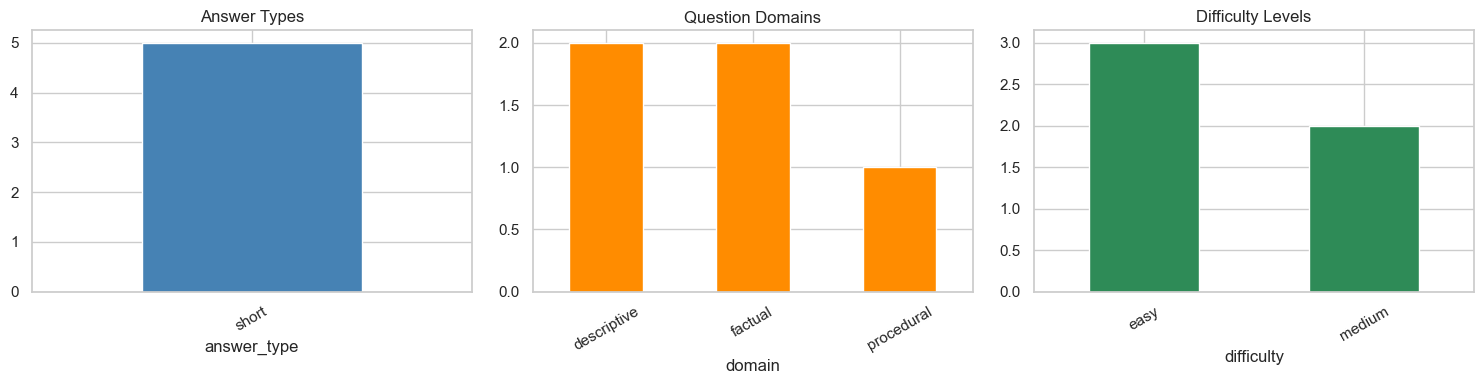

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['answer_type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Answer Types'); axes[0].tick_params(axis='x', rotation=30)

df['domain'].value_counts().plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Question Domains'); axes[1].tick_params(axis='x', rotation=30)

df['difficulty'].value_counts().plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Difficulty Levels'); axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../data/dataset_stats.png', dpi=150)
plt.show()

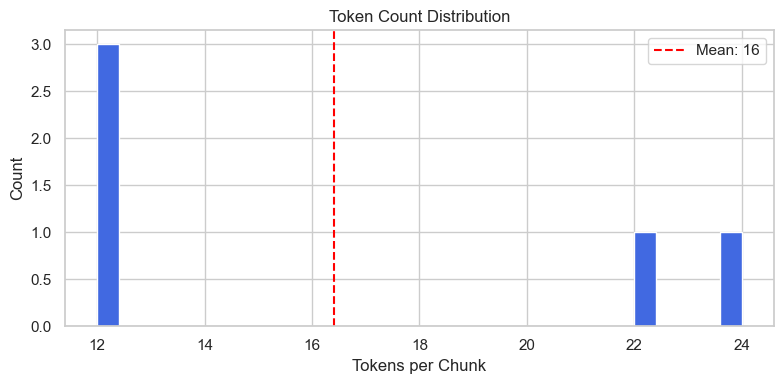

In [11]:
# Token count distribution
plt.figure(figsize=(8, 4))
plt.hist(df['token_count'], bins=30, color='royalblue', edgecolor='white')
plt.xlabel('Tokens per Chunk'); plt.ylabel('Count')
plt.title('Token Count Distribution')
plt.axvline(df['token_count'].mean(), color='red', linestyle='--', label=f'Mean: {df["token_count"].mean():.0f}')
plt.legend(); plt.tight_layout(); plt.show()

## 2. Chunking Strategy Demonstration

In [12]:
from src.data.processor import chunk_text

long_text = """
Machine learning is a type of artificial intelligence that allows software applications 
to become more accurate at predicting outcomes without being explicitly programmed to do so. 
Machine learning algorithms use historical data as input to predict new output values. 
This approach is valuable in many domains including healthcare, finance, and natural language processing.
Deep learning is a subset of machine learning that uses neural networks with many layers.
These neural networks can learn hierarchical representations of data automatically.
Convolutional neural networks are particularly effective for image recognition tasks.
Recurrent neural networks are designed for sequential data like text and time series.
Transformers have revolutionised natural language processing since their introduction in 2017.
""".strip()

for chunk_size in [200, 350, 512]:
    chunks = chunk_text(long_text, chunk_size=chunk_size, overlap=50)
    print(f'chunk_size={chunk_size}: {len(chunks)} chunks, avg_len={sum(len(c) for c in chunks)//len(chunks)}')
    for i, c in enumerate(chunks):
        print(f'  [{i}] {c[:80]}...')

chunk_size=200: 8 chunks, avg_len=145
  [0] Machine learning is a type of artificial intelligence that allows software appli...
  [1] omes without being explicitly programmed to do so. Machine learning algorithms u...
  [2] orical data as input to predict new output values. This approach is valuable in ...
  [3] lthcare, finance, and natural language processing. Deep learning is a subset of ...
  [4] arning that uses neural networks with many layers. These neural networks can lea...
  [5] ierarchical representations of data automatically. Convolutional neural networks...
  [6] articularly effective for image recognition tasks. Recurrent neural networks are...
  [7] ned for sequential data like text and time series. Transformers have revolutioni...
chunk_size=350: 3 chunks, avg_len=305
  [0] Machine learning is a type of artificial intelligence that allows software appli...
  [1] orical data as input to predict new output values. This approach is valuable in ...
  [2] ierarchical repres

## 3. Embedding & Retrieval Demo

In [13]:
from src.embeddings.engine import EmbeddingEngine
from src.retrieval.vector_store import VectorStore
from src.retrieval.query_processor import QueryProcessor
from src.retrieval.retriever import Retriever

# Build a small in-memory index from the processed docs
engine = EmbeddingEngine()
vs = VectorStore(index_path='./data/demo_index')

if not vs.load():
    vs.build_from_documents(documents, engine)
    vs.save()

qp = QueryProcessor()
retriever = Retriever(vs, engine)
retriever.fit_keyword_scorer(documents)

print(f'Index size: {vs.size} vectors')

2026-03-30 11:21:30 [info     ] Loaded index with 5 vectors from data\demo_index
2026-03-30 11:21:30 [info     ] Keyword scorer fitted on 5 documents.
Index size: 5 vectors


In [1]:
# Interactive retrieval
queries = [
    'What is machine learning?',
    'How does photosynthesis work?',
    'Who invented the telephone?',
]

for query in queries:
    processed = qp.process(query)
    results = retriever.retrieve(processed, top_k=3)
    print(f'\nQuery: "{query}"')
    print(f'Expanded: "{processed.expanded}"')
    for r in results:
        print(f'  [{r.rank+1}] score={r.final_score:.3f} | {r.document.text[:100]}...')

NameError: name 'qp' is not defined

## 4. Evaluation Metrics Demo

In [15]:
from src.evaluation.evaluator import (
    precision_at_k, recall_at_k, reciprocal_rank, ndcg_at_k,
    exact_match, token_f1, rouge_scores, bleu_score
)

# Simulated retrieval scenario
retrieved = ['doc_a', 'doc_b', 'doc_c', 'doc_d', 'doc_e']
relevant  = {'doc_a', 'doc_c', 'doc_f'}

print('=== Retrieval Metrics ===')
for k in [1, 3, 5]:
    print(f'  Precision@{k}: {precision_at_k(retrieved, relevant, k):.3f}')
    print(f'  Recall@{k}:    {recall_at_k(retrieved, relevant, k):.3f}')
    print(f'  NDCG@{k}:      {ndcg_at_k(retrieved, relevant, k):.3f}')
print(f'  MRR:           {reciprocal_rank(retrieved, relevant):.3f}')

print('\n=== Generation Metrics ===')
pred = 'Paris is the capital city of France'
ref  = 'The capital of France is Paris'
print(f'  Exact Match: {exact_match(pred, ref)}')
print(f'  Token F1:    {token_f1(pred, ref):.3f}')
r = rouge_scores(pred, ref)
print(f'  ROUGE-1:     {r["rouge1"]:.3f}')
print(f'  ROUGE-L:     {r["rougeL"]:.3f}')
print(f'  BLEU:        {bleu_score(pred, ref):.3f}')

=== Retrieval Metrics ===
  Precision@1: 1.000
  Recall@1:    0.333
  NDCG@1:      1.000
  Precision@3: 0.667
  Recall@3:    0.667
  NDCG@3:      0.704
  Precision@5: 0.400
  Recall@5:    0.667
  NDCG@5:      0.704
  MRR:           1.000

=== Generation Metrics ===
  Exact Match: 0.0
  Token F1:    0.923
  ROUGE-1:     0.923
  ROUGE-L:     0.615
  BLEU:        0.165


## 5. Embedding Space Visualisation (UMAP)

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


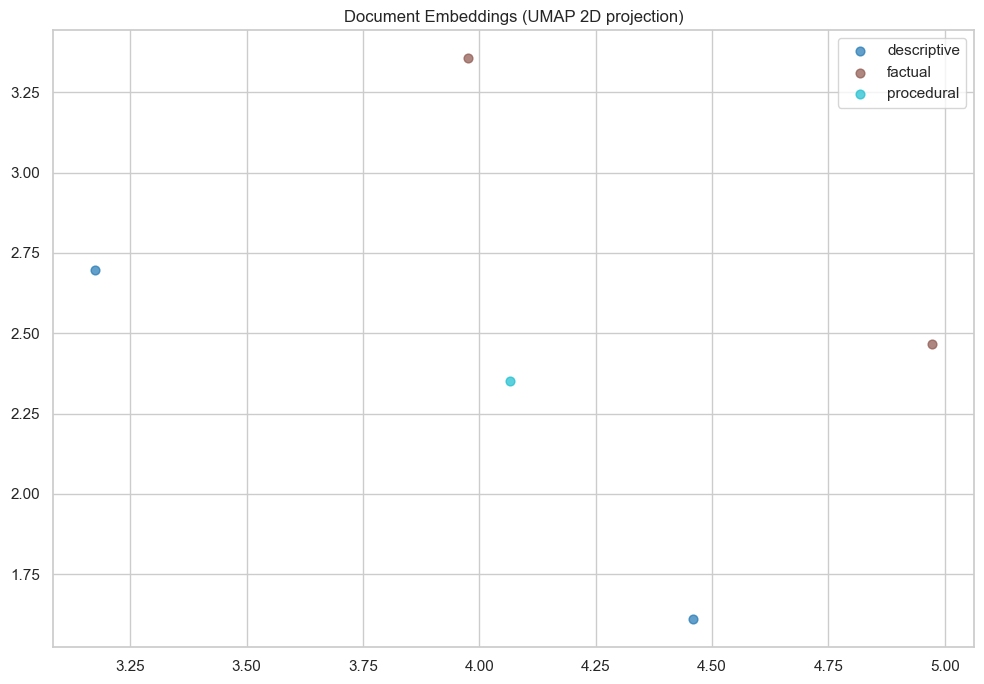

In [16]:
# Requires: pip install umap-learn
try:
    import umap
    texts  = [d.text for d in documents[:100]]
    labels = [d.domain for d in documents[:100]]
    embs   = engine.embed(texts)

    reducer = umap.UMAP(n_components=2, random_state=42)
    proj    = reducer.fit_transform(embs)

    unique_labels = list(set(labels))
    colours       = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
    label_colour  = {l: c for l, c in zip(unique_labels, colours)}

    plt.figure(figsize=(10, 7))
    for label in unique_labels:
        idx = [i for i, l in enumerate(labels) if l == label]
        plt.scatter(proj[idx, 0], proj[idx, 1], label=label,
                    c=[label_colour[label]], alpha=0.7, s=40)
    plt.legend(); plt.title('Document Embeddings (UMAP 2D projection)')
    plt.tight_layout()
    plt.savefig('../data/embedding_umap.png', dpi=150)
    plt.show()
except ImportError:
    print('Install umap-learn to visualise: pip install umap-learn')